# Telco Customer Churn Prediction & Retention Insights

## 1. Imports and Global Settings

In [202]:
# 1. Imports & Settings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

## 2. Data Loading and Initial Inspection

In [203]:
# 2. Load Data

file_path = "/content/WA_Fn-UseC_-Telco-Customer-Churn - WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

print(df.shape)
df.head(10)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## 3. Data Cleaning and Type Fixes

In [204]:
# 3.1 Structure & Missing Values

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [205]:
# 3.2 Treat TotalCharges (often comes as object with spaces)

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = df["TotalCharges"].astype(float)

print(df["TotalCharges"].isna().sum())
df[df["TotalCharges"].isna()].head()

11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No


In [206]:
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
df.shape

(7032, 21)

In [207]:
# 3.3 Basic stats

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7032,7032,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7032.0,NaN,NaN,NaN,0.1624,0.368844,0.0,0.0,0.0,0.0,1.0
Partner,7032,2,No,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7032,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7032.0,NaN,NaN,NaN,32.421786,24.54526,1.0,9.0,29.0,55.0,72.0
PhoneService,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7032,3,No,3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Feature Engineering and Helper Columns

In [208]:
# 4.1 Binary encode target Churn

df["Churn_Flag"] = df["Churn"].map({"No": 0, "Yes": 1})

# 4.2 Numerical & categorical feature lists (excluding IDs/target)

id_cols = ["customerID"]
target_cols = ["Churn", "Churn_Flag"]

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [
    col for col in df.columns
    if col not in id_cols + target_cols + num_cols
]

num_cols, cat_cols

(['tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

## 5. Univariate Analysis (Target and Features)
###5.1 Target (Churn)


Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


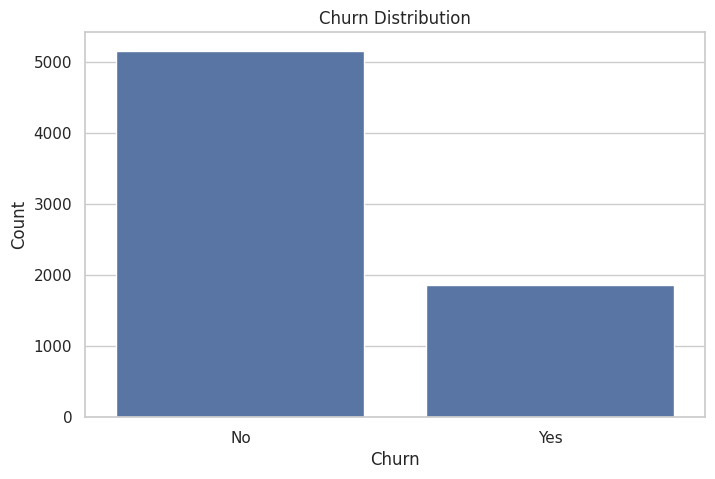

In [209]:
# 5.1 Churn distribution

churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.ylabel("Count")
plt.show()

###5.2 Numerical Features

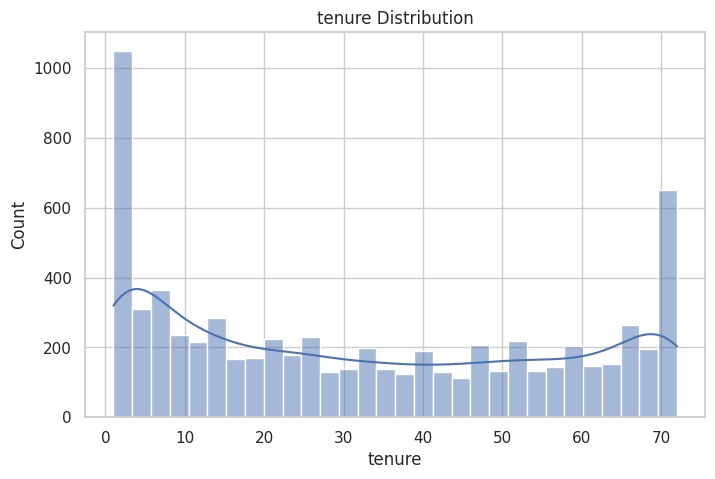

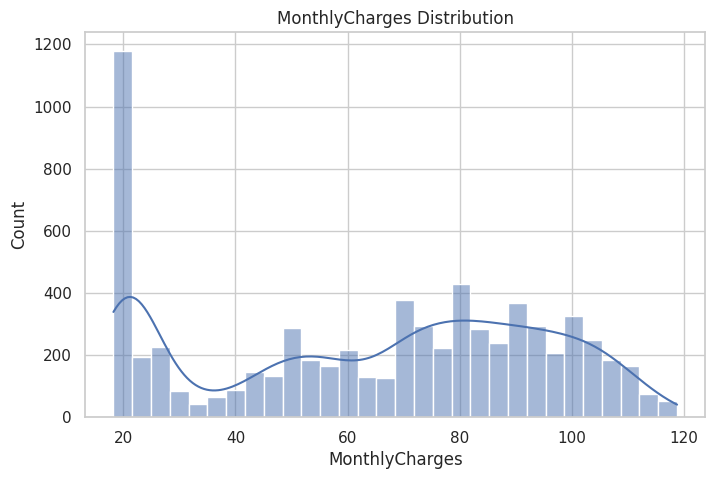

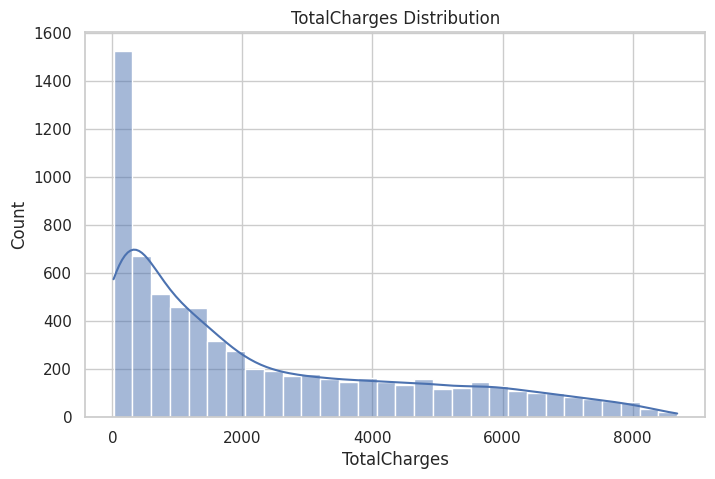

In [210]:
# 5.2.1 Histograms

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"{col} Distribution")
    plt.show()


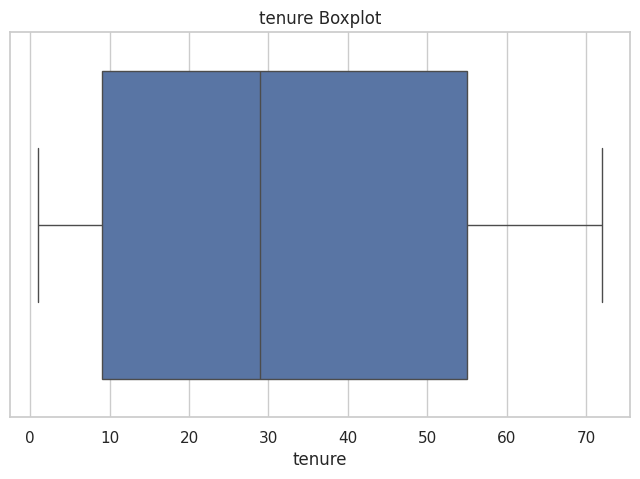

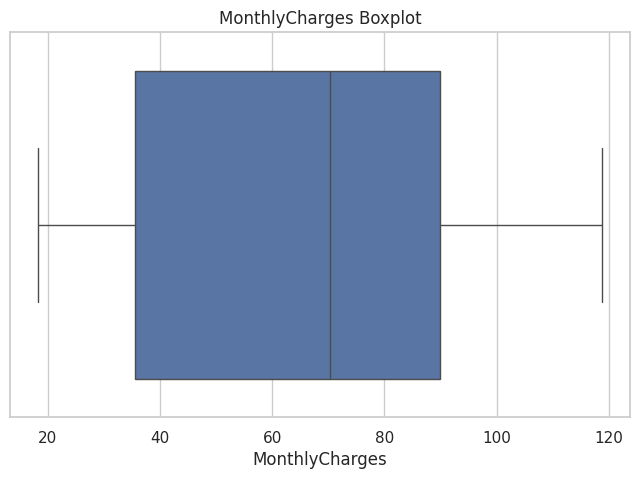

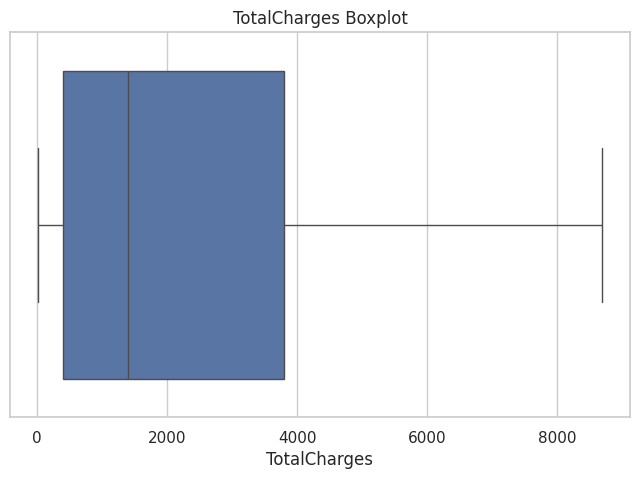

In [211]:
# 5.2.2 Boxplots

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()


###5.3 Categorical Features

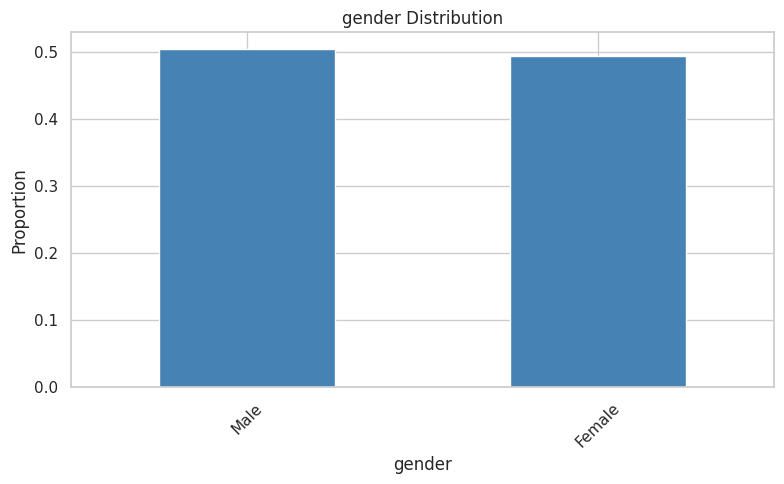

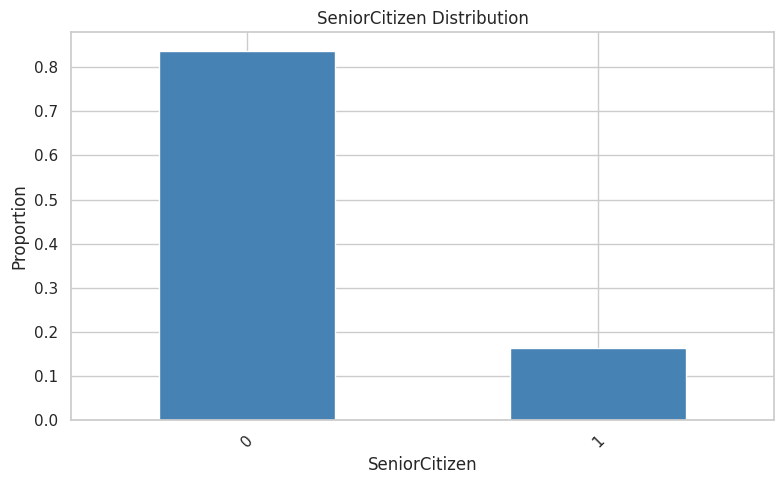

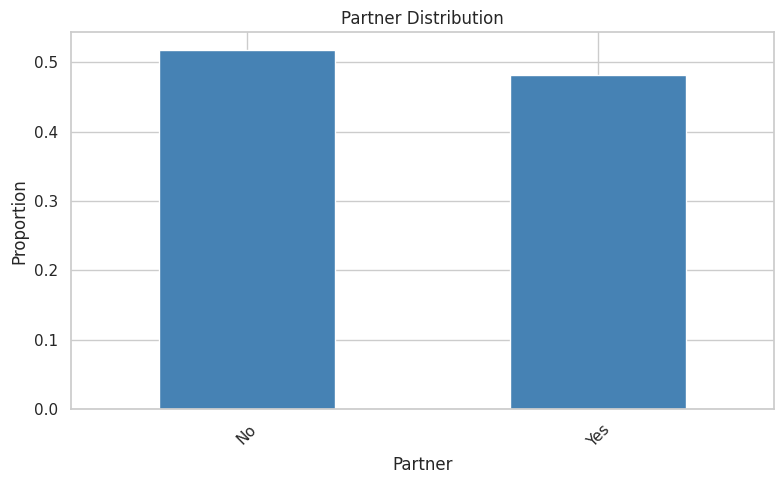

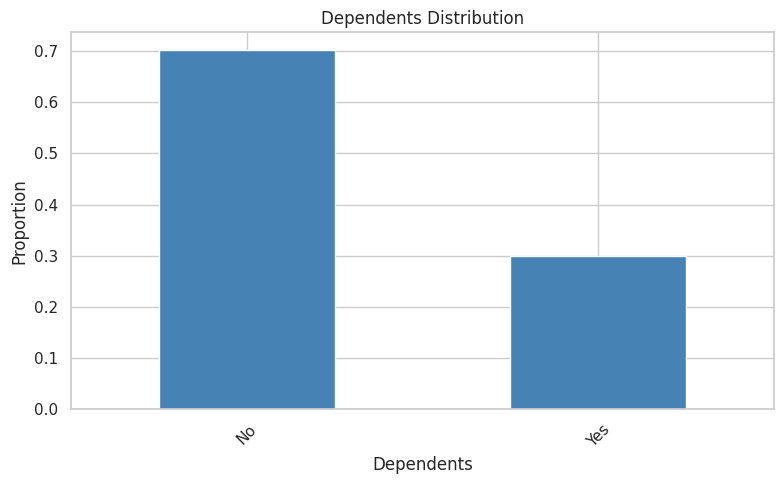

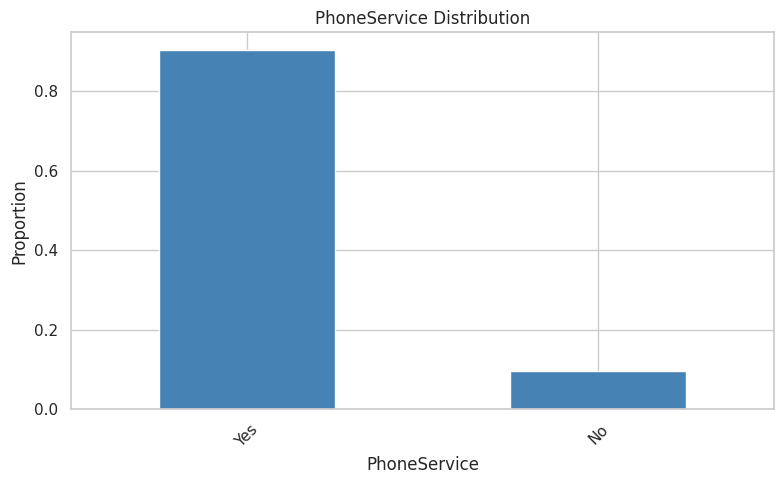

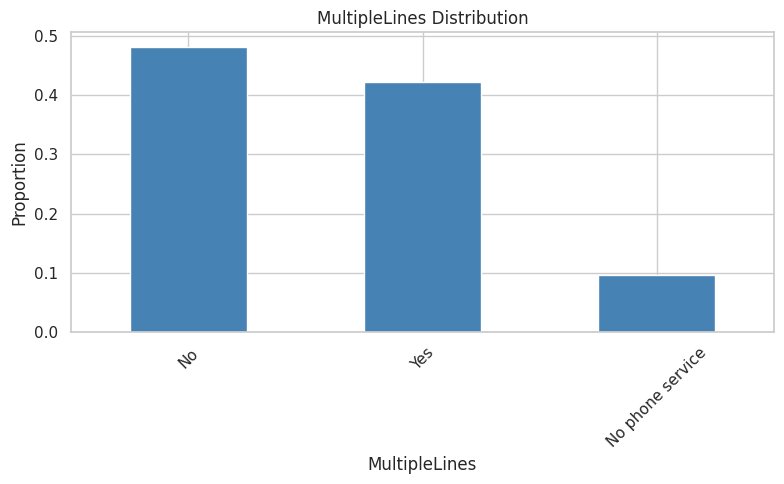

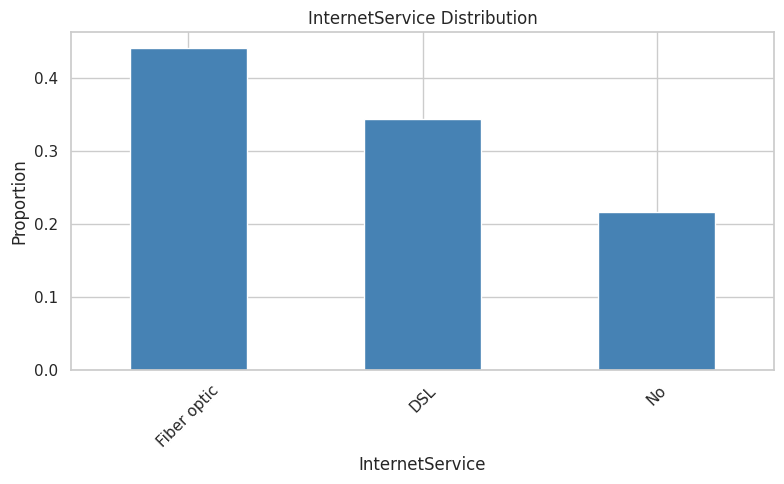

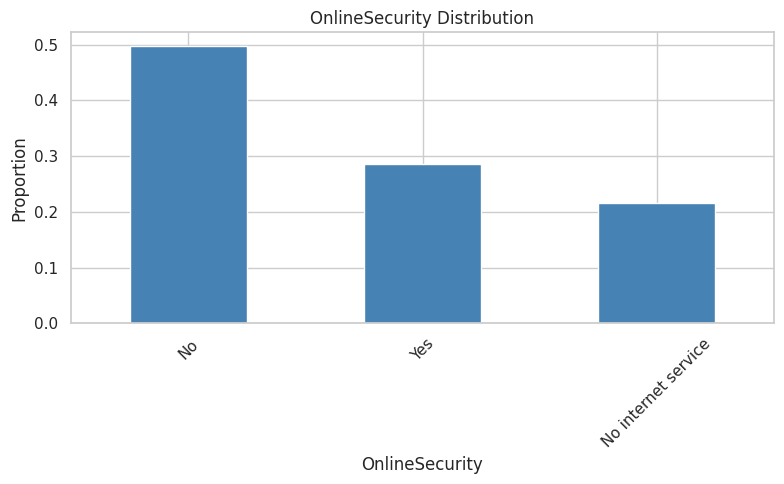

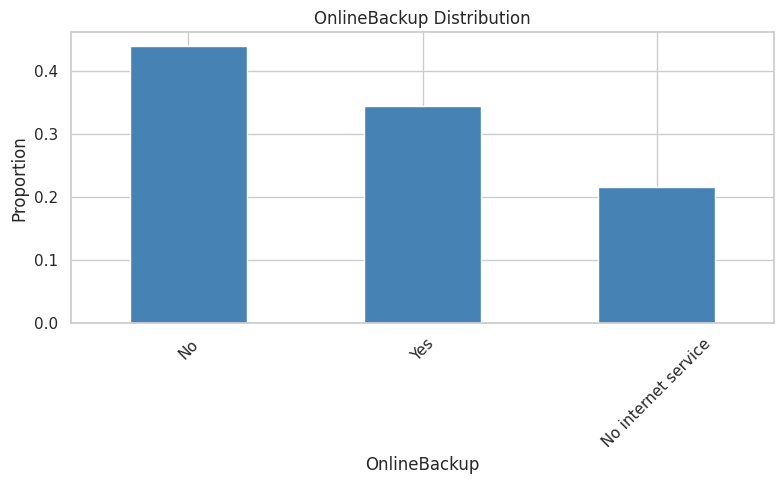

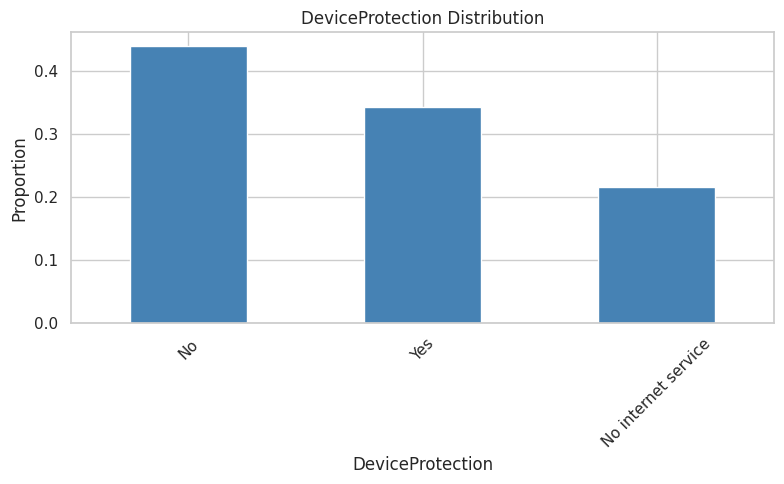

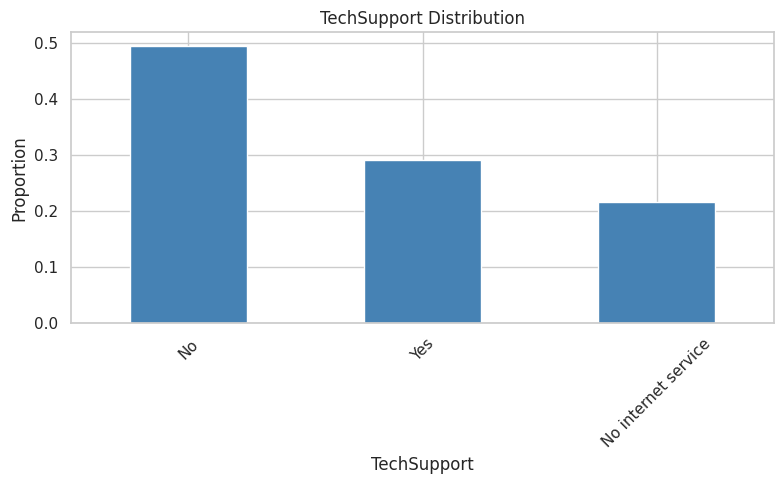

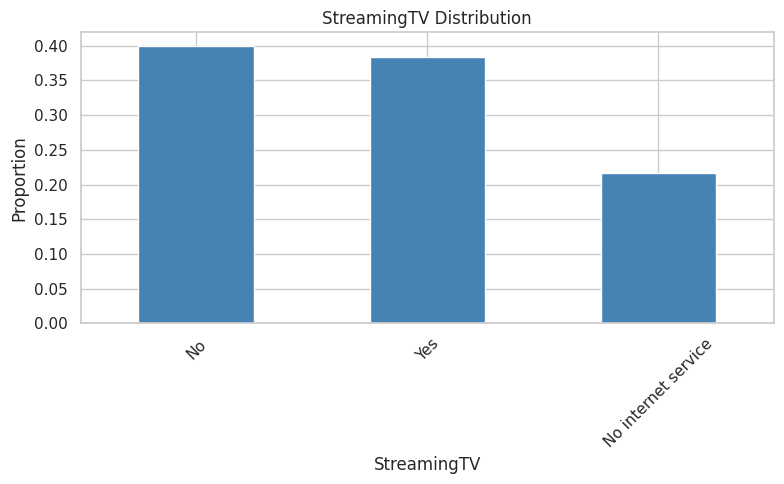

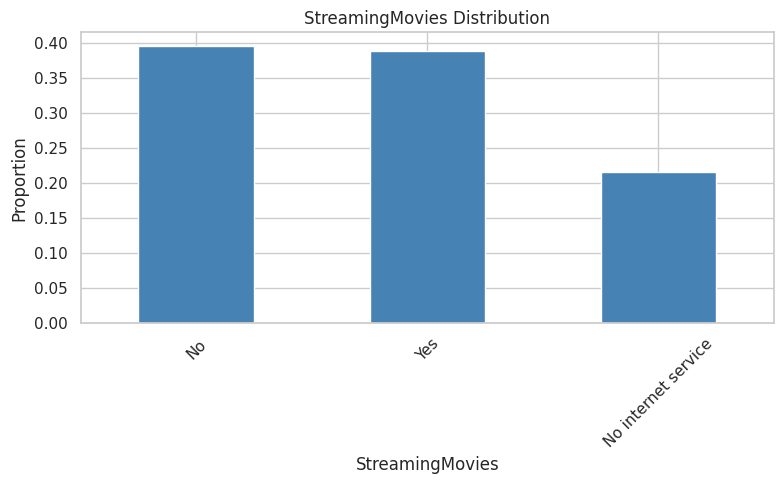

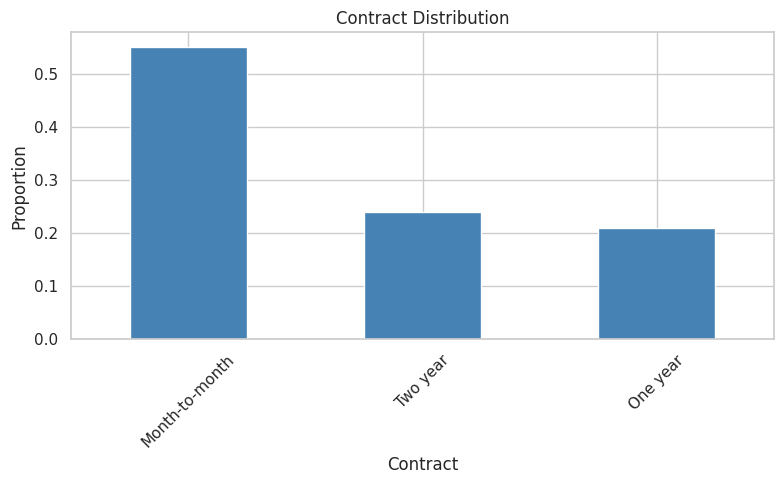

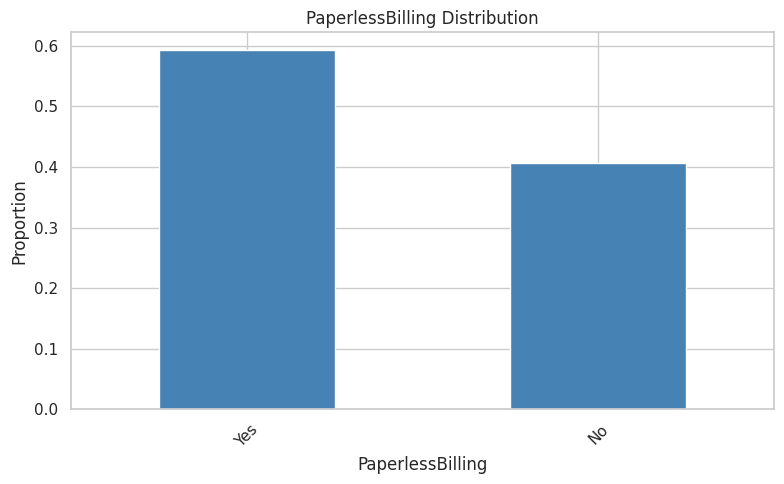

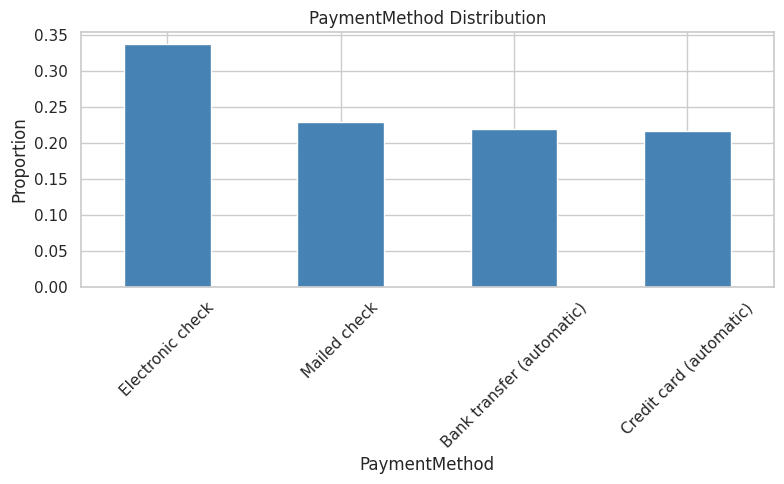

In [212]:
# 5.3 Category counts for each categorical feature

for col in cat_cols:
    plt.figure()
    df[col].value_counts(normalize=True).plot(
        kind="bar", color="steelblue"
    )
    plt.title(f"{col} Distribution")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 6. Bivariate Analysis and Business Insights
###6.1 Churn vs Categorical Features

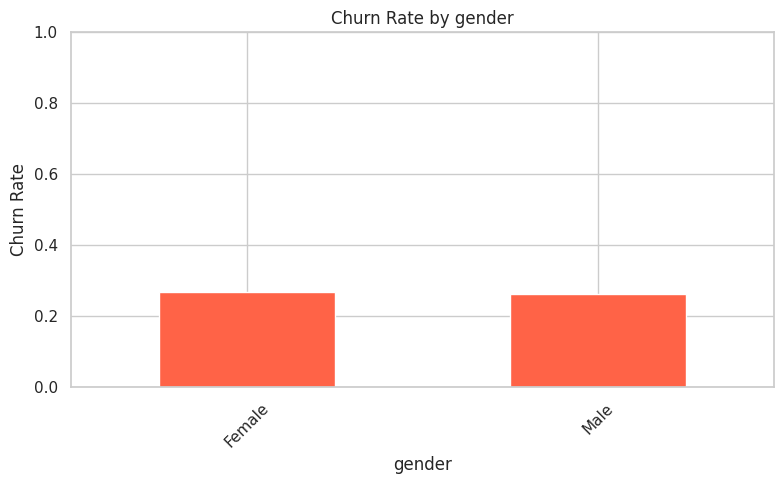

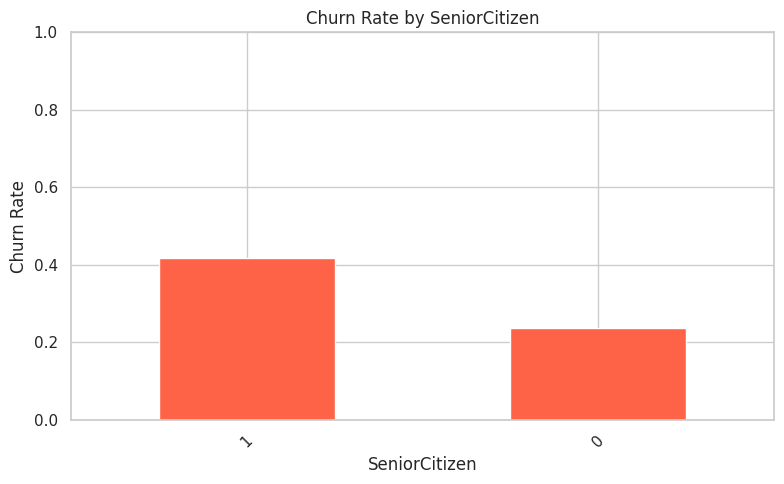

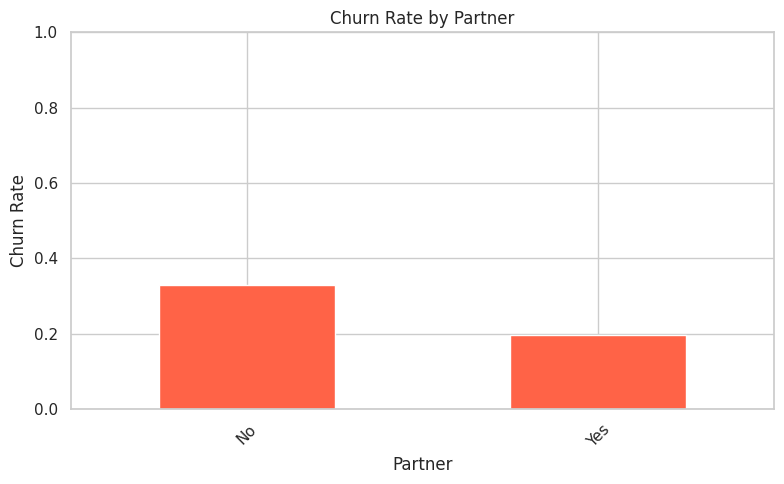

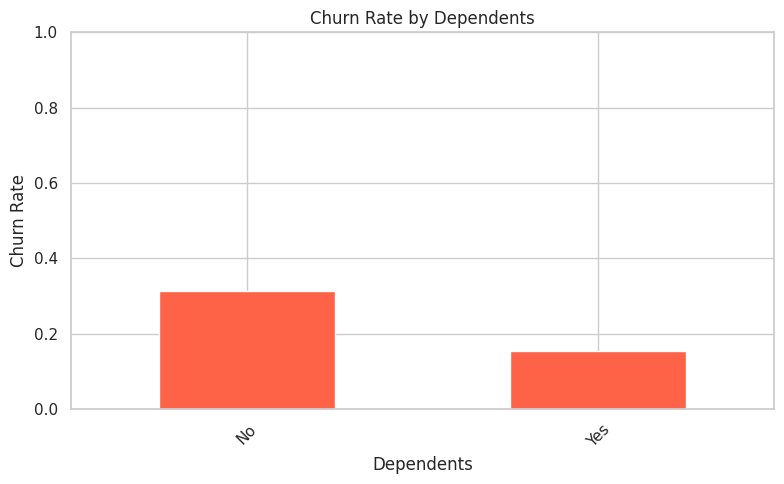

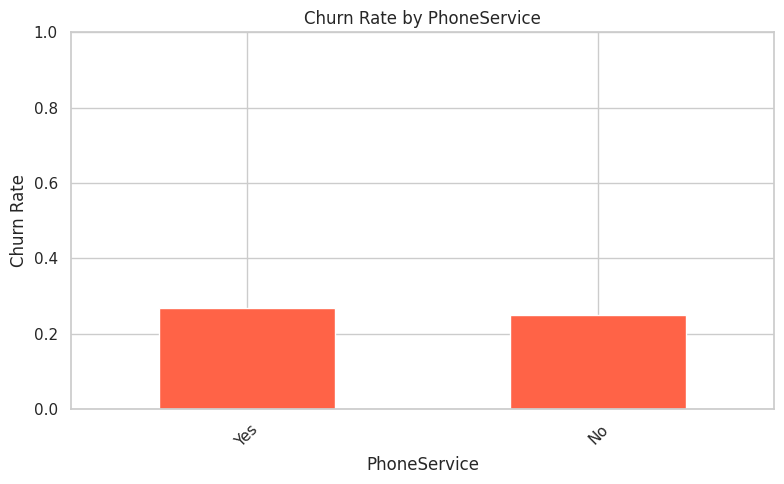

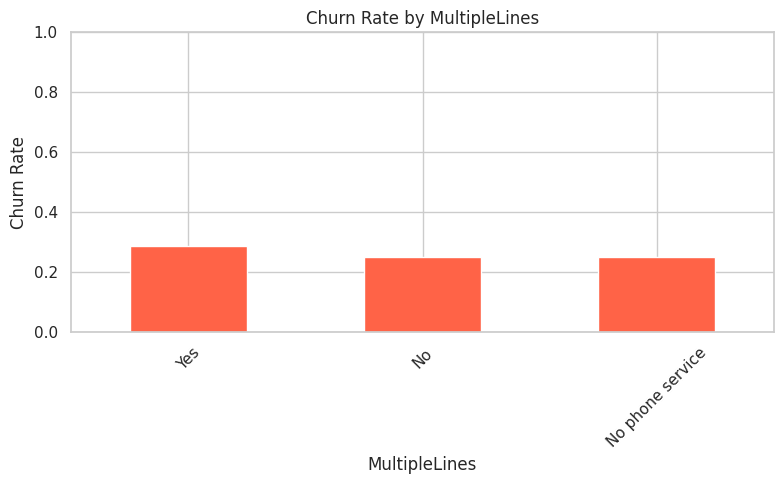

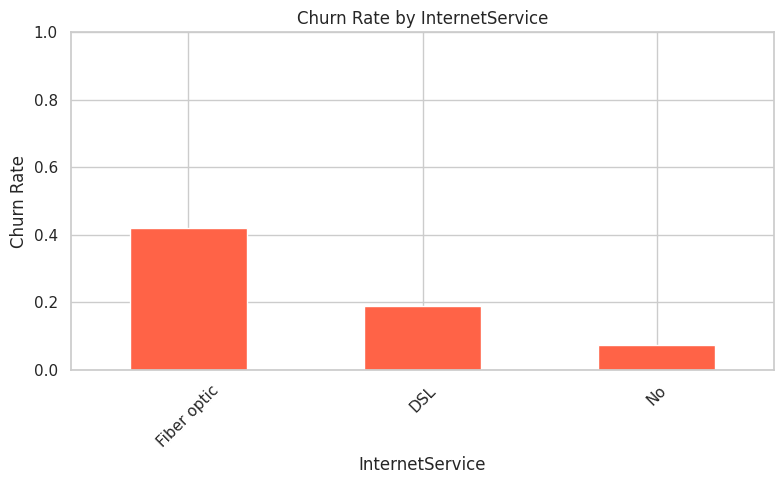

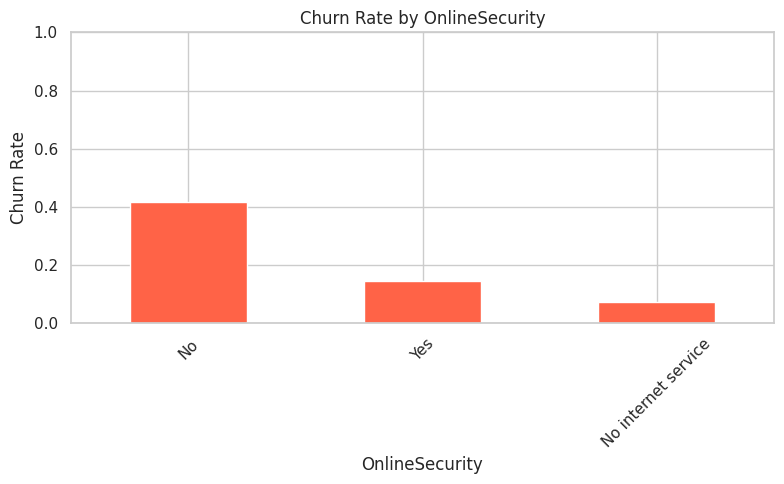

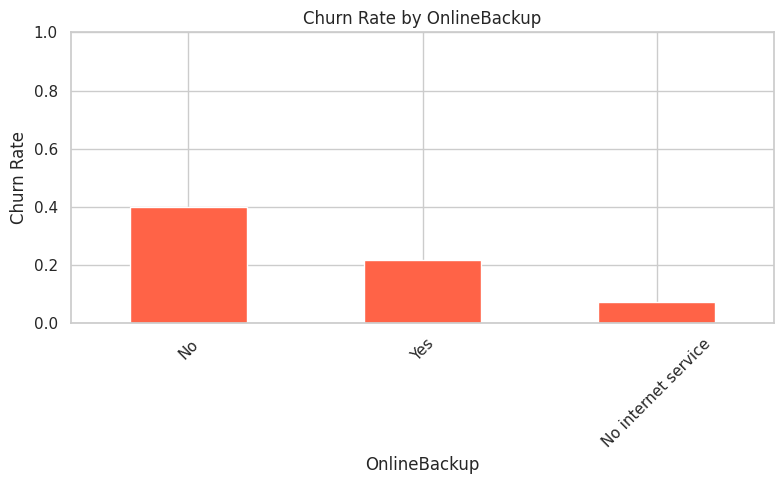

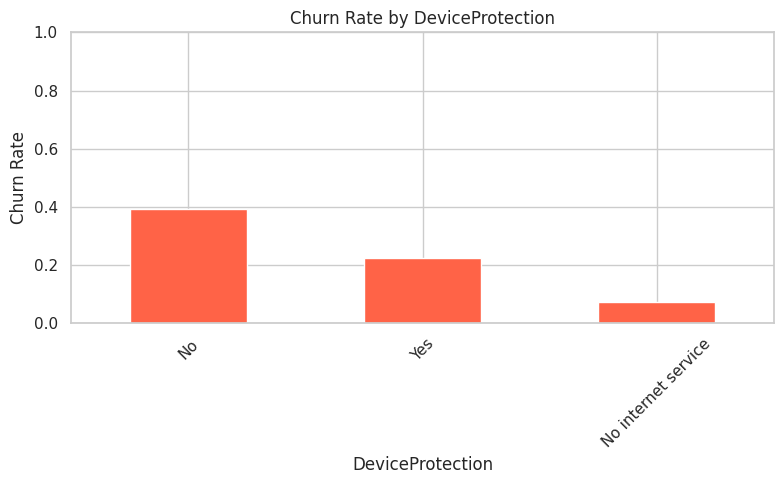

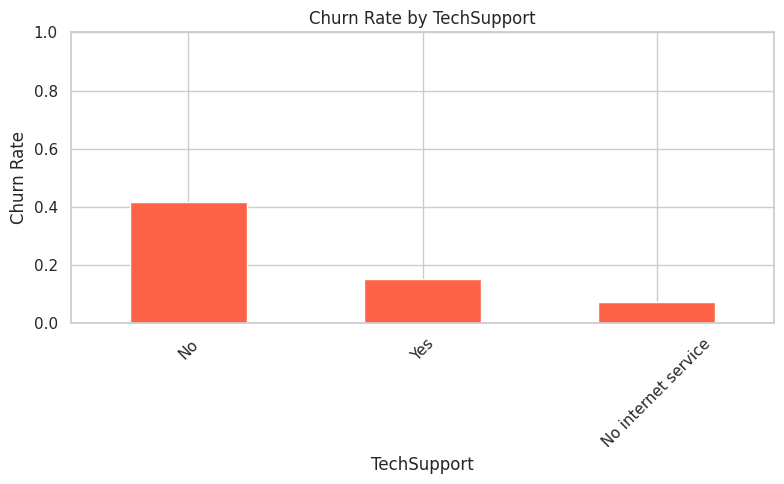

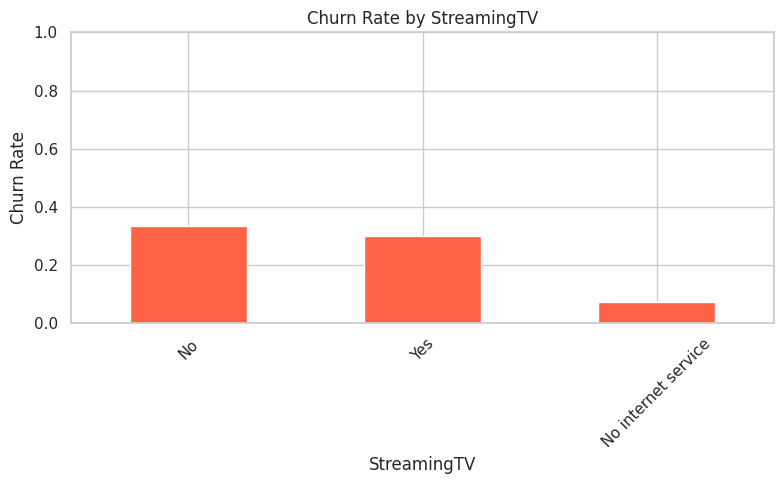

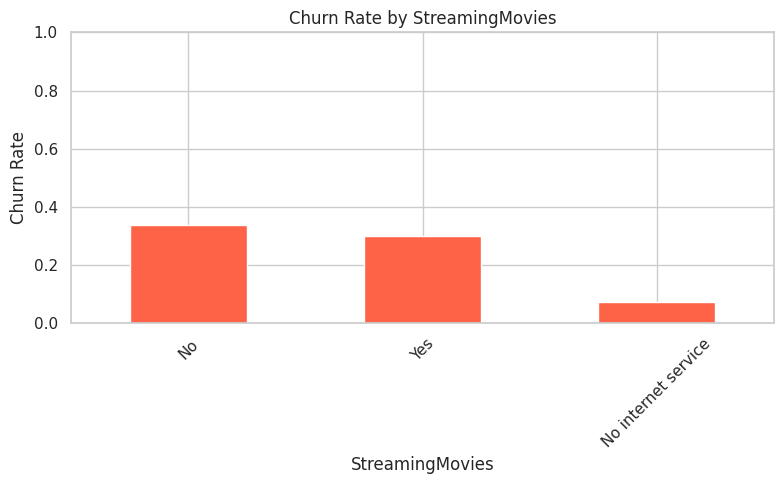

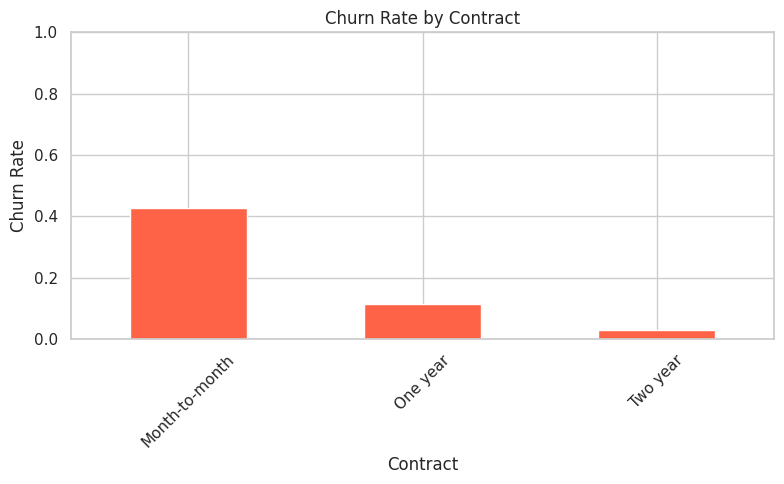

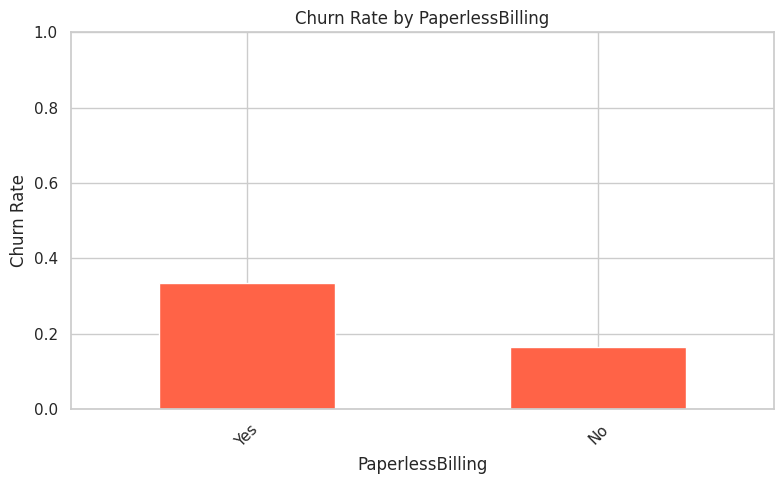

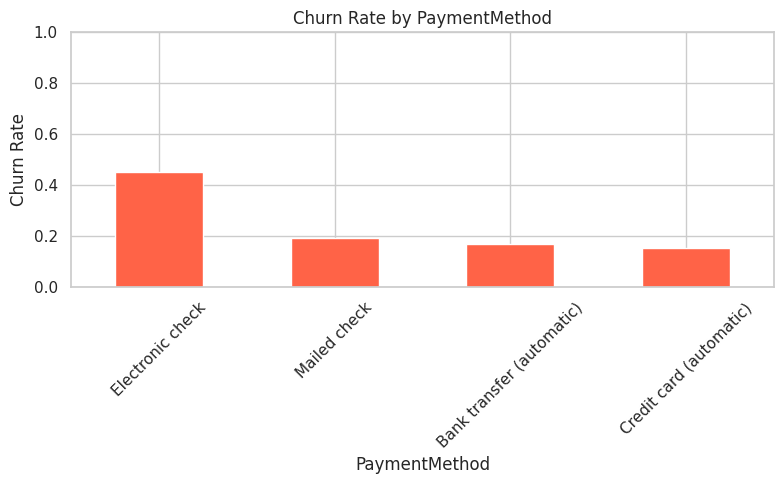

In [213]:
# 6.1 Churn rate by category for each categorical feature

def plot_churn_rate_by_category(df, col):
    churn_rate = (
        df.groupby(col)["Churn_Flag"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure()
    churn_rate.plot(kind="bar", color="tomato")
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    plot_churn_rate_by_category(df, col)

####6.2 Churn vs Numerical Features

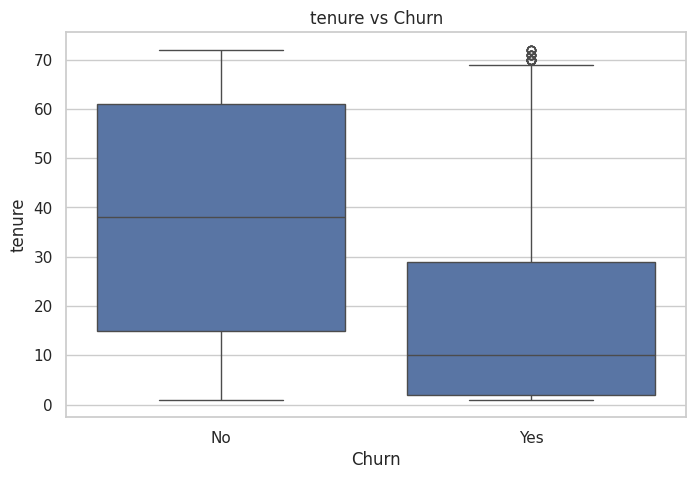

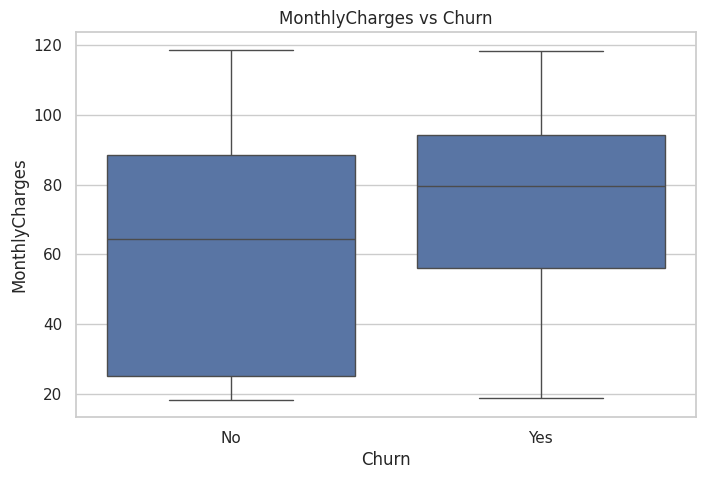

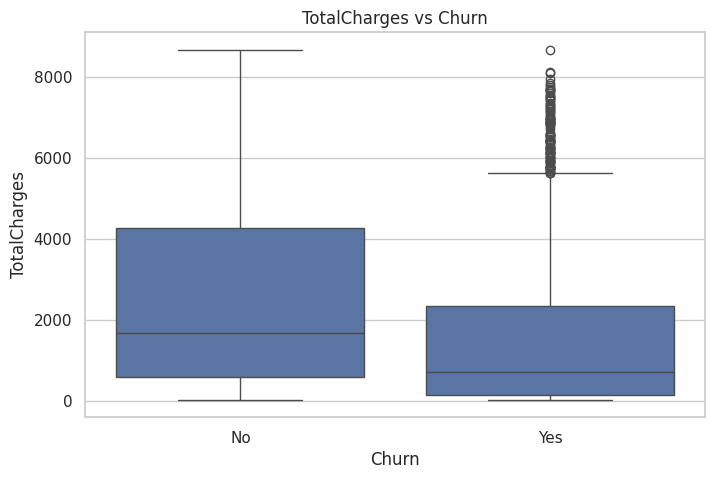

In [214]:
# 6.2.2 Boxplots by churn

for col in num_cols:
    plt.figure()
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

###7) Multivariate Analysis
####7.1 Correlation Between Numerical Features and Churn_Flag


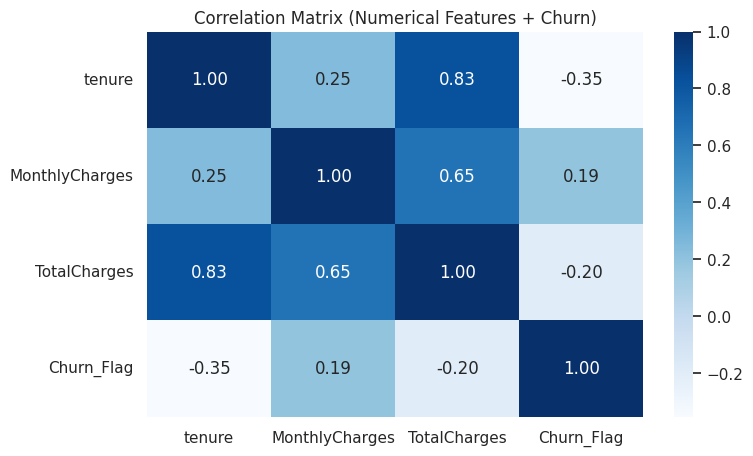

In [215]:
# 7.1 Correlation matrix

corr_cols = num_cols + ["Churn_Flag"]
corr = df[corr_cols].corr()

sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix (Numerical Features + Churn)")
plt.show()


####7.2 Contract × PaymentMethod × Churn


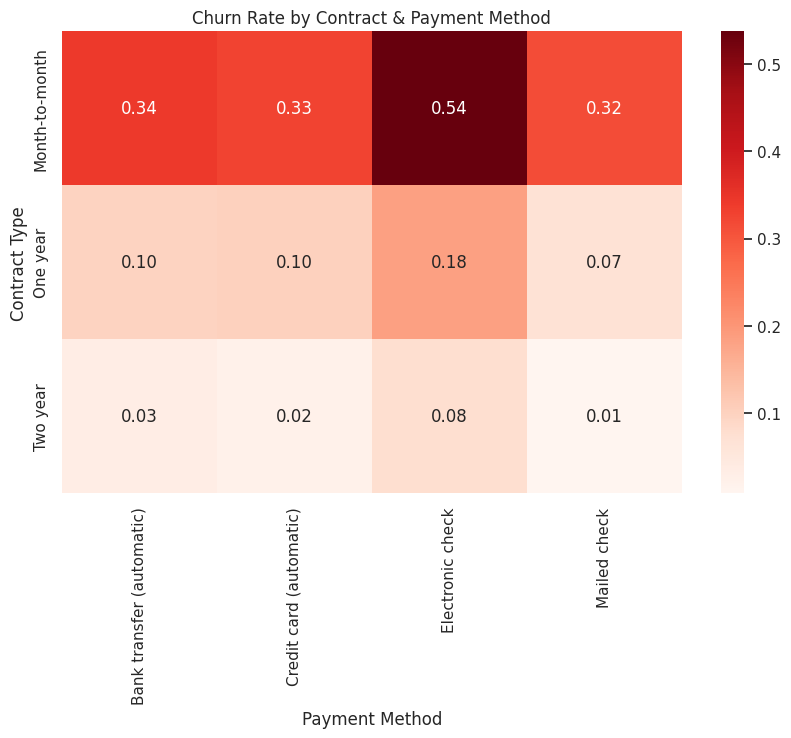

In [216]:
# 7.2 Combined categories: Contract & PaymentMethod

pivot_cp = (
    df.pivot_table(
        index="Contract",
        columns="PaymentMethod",
        values="Churn_Flag",
        aggfunc="mean"
    )
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_cp, annot=True, cmap="Reds", fmt=".2f")
plt.title("Churn Rate by Contract & Payment Method")
plt.ylabel("Contract Type")
plt.xlabel("Payment Method")
plt.show()


####7.3 InternetService × OnlineSecurity × Churn


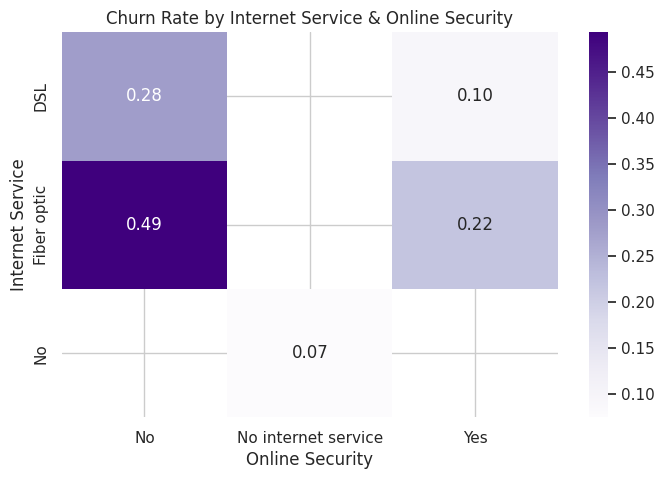

In [217]:
# 7.3 Effect of security services within each Internet type

pivot_is_sec = (
    df.pivot_table(
        index="InternetService",
        columns="OnlineSecurity",
        values="Churn_Flag",
        aggfunc="mean"
    )
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_is_sec, annot=True, cmap="Purples", fmt=".2f")
plt.title("Churn Rate by Internet Service & Online Security")
plt.ylabel("Internet Service")
plt.xlabel("Online Security")
plt.show()


####7.4 Tenure Buckets × Churn


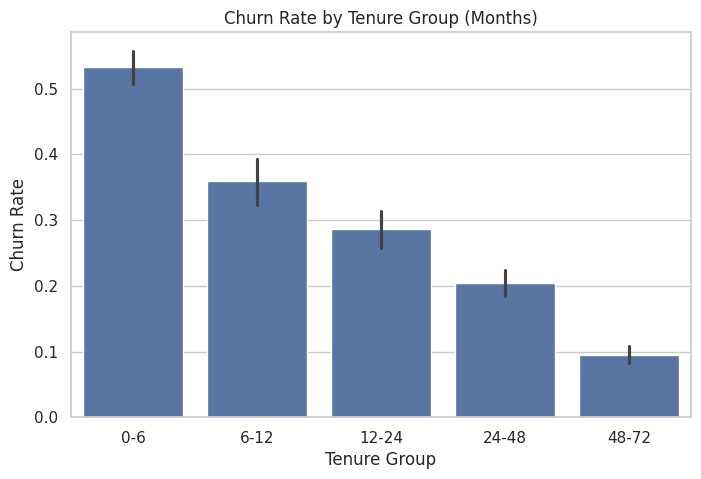

In [218]:
# 7.4 Tenure buckets

bins = [0, 6, 12, 24, 48, 72]
labels = ["0-6", "6-12", "12-24", "24-48", "48-72"]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels, right=True)

plt.figure()
sns.barplot(
    x="tenure_group",
    y="Churn_Flag",
    data=df,
    order=labels
)
plt.title("Churn Rate by Tenure Group (Months)")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group")
plt.show()


##### 8. Statistical Tests for Churn Drivers
####8.1 Chi‑Square for Categorical Features


In [219]:
# 8.1 Chi-square test of independence between feature and Churn

def chi_square_test(df, col):
    ct = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, ex = chi2_contingency(ct)
    return p

chi_results = {
    col: chi_square_test(df, col)
    for col in cat_cols
}

chi_df = (
    pd.Series(chi_results, name="p_value")
    .sort_values()
    .to_frame()
)

chi_df


,p_value
Contract,7.326182e-257
OnlineSecurity,1.400687e-184
TechSupport,7.407808e-180
InternetService,5.831199e-159
PaymentMethod,1.426310e-139
OnlineBackup,7.776099e-131
DeviceProtection,1.959389e-121
StreamingMovies,5.353560e-82
StreamingTV,1.324641e-81
PaperlessBilling,8.236203e-58


## 9. Retention Insights & Recommendations

Based on the EDA, several patterns stand out:

1. **Contract Type**
   - Month-to-month customers have significantly higher churn compared to one-year and two-year contracts.
   - 👉 Business action:
     - Design incentives to move month-to-month customers to longer contracts (discounts, loyalty points, bundled offers).

2. **Tenure**
   - New customers (0–6 months) show the highest churn.
   - 👉 Business action:
     - Implement an onboarding / “welcome” program:
       - Proactive check-in calls in the first 3 months
       - Educational emails about services and benefits
       - Short-term discounts or upgrades to increase early satisfaction.

3. **Internet & Security Services**
   - Customers with Fiber optic but without OnlineSecurity / TechSupport show higher churn than DSL customers with protection.
   - 👉 Business action:
     - Offer low-cost security/tech support add-ons for fiber customers.
     - Bundle security packages with fiber plans and communicate the value clearly.

4. **Payment Method**
   - Electronic check users tend to have higher churn compared to automatic bank transfer / credit card.
   - 👉 Business action:
     - Promote automatic payment methods (bank transfer / credit card) with small discounts or rewards.
     - Reduce friction in switching payment methods (simple online flow).

5. **MonthlyCharges & TotalCharges**
   - Higher MonthlyCharges are often associated with higher churn, especially for short-tenure customers.
   - 👉 Business action:
     - Review pricing for high-ARPU segments with high churn.
     - Introduce flexible plans, temporary discounts, or personalized offers before renewal.

These insights can be used to design targeted retention campaigns focusing on:
- New customers in their first 6–12 months
- Month-to-month contracts
- Fiber customers without security add-ons
- Customers paying via electronic check with high monthly charges.


## 10. Modeling Dataset Preparation

In [220]:
# 1. Copy DF and keep only needed columns
model_df = df.copy()

# Drop ID columns
model_df = model_df.drop(columns=['customerID'])

# Encode target
model_df['ChurnFlag'] = model_df['Churn'].map({'No': 0, 'Yes': 1})

# Numerical & Categorical
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in model_df.columns if c not in num_cols + ['Churn', 'ChurnFlag']]

# One‑Hot Encoding
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

# Train / Test split
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=['Churn', 'ChurnFlag'])
y = model_df['ChurnFlag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((4922, 35), (2110, 35))

## 11. Model Training and Evaluation
###11.1. Logistic Regression


In [221]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

log_clf = LogisticRegression(max_iter=500, class_weight='balanced', n_jobs=-1)
log_clf.fit(X_train, y_train)

y_pred_log = log_clf.predict(X_test)
y_proba_log = log_clf.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1549
           1       1.00      1.00      1.00       561

    accuracy                           1.00      2110
   macro avg       1.00      1.00      1.00      2110
weighted avg       1.00      1.00      1.00      2110

ROC-AUC: 1.0


##11.2. Random Forest


In [222]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1549
           1       1.00      1.00      1.00       561

    accuracy                           1.00      2110
   macro avg       1.00      1.00      1.00      2110
weighted avg       1.00      1.00      1.00      2110

ROC-AUC: 1.0


##11.3. Gradient Boosting (Sklearn)


In [223]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    random_state=RANDOM_STATE
)
gb_clf.fit(X_train, y_train)

y_pred_gb = gb_clf.predict(X_test)
y_proba_gb = gb_clf.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gb))


Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1549
           1       1.00      1.00      1.00       561

    accuracy                           1.00      2110
   macro avg       1.00      1.00      1.00      2110
weighted avg       1.00      1.00      1.00      2110

ROC-AUC: 1.0


In [224]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

# تأكد من إن y_pred فعلاً جاي من X_test مش X_train
print("Logistic uses X_test only?  ", len(y_pred_log) == len(X_test))
print("RandomForest uses X_test?  ", len(y_pred_rf) == len(X_test))
print("GradientBoost uses X_test?", len(y_pred_gb) == len(X_test))

print("\nSample of y_test:", y_test[:10].values)
print("Sample of y_pred_log:", y_pred_log[:10])
print("Sample of y_pred_rf :", y_pred_rf[:10])
print("Sample of y_pred_gb :", y_pred_gb[:10])

X_train shape: (4922, 35)
X_test shape : (2110, 35)
Logistic uses X_test only?   True
RandomForest uses X_test?   True
GradientBoost uses X_test? True

Sample of y_test: [0 0 0 0 0 0 0 0 0 1]
Sample of y_pred_log: [0 0 0 0 0 0 0 0 0 1]
Sample of y_pred_rf : [0 0 0 0 0 0 0 0 0 1]
Sample of y_pred_gb : [0 0 0 0 0 0 0 0 0 1]


#### 12. Model Explainability (Feature Importance)

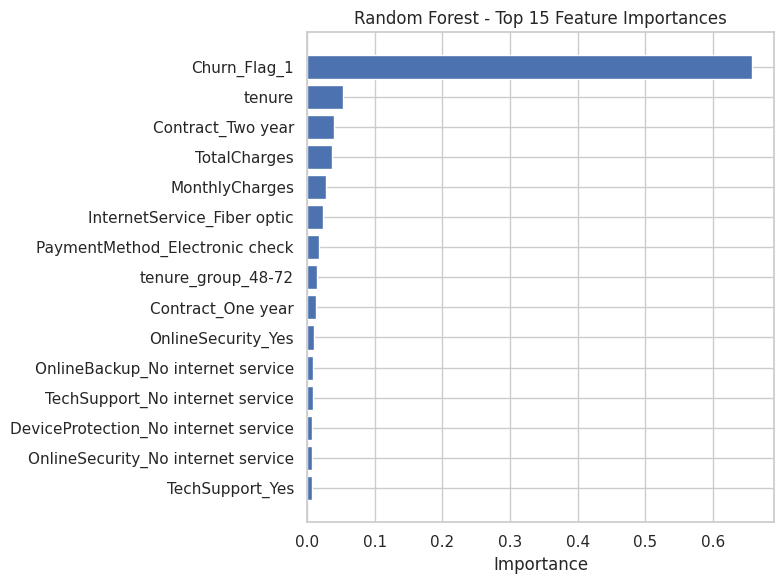

In [225]:
import numpy as np
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15

plt.figure(figsize=(8, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


##13. Precision, Recall and F1 for Churn Class Across Models

In [226]:
print("Unique values in y_test:", np.unique(y_test, return_counts=True))
print("Logistic correct:", (y_test == y_pred_log).mean())
print("RandomForest correct:", (y_test == y_pred_rf).mean())
print("GradientBoosting correct:", (y_test == y_pred_gb).mean())

Unique values in y_test: (array([0, 1]), array([1549,  561]))
Logistic correct: 1.0
RandomForest correct: 1.0
GradientBoosting correct: 1.0


In [227]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd

# Compute precision and recall for the churn class (positive class = 1)
comparison = []

comparison.append({
    "model": "Logistic Regression",
    "precision_churn": precision_score(y_test, y_pred_log),
    "recall_churn": recall_score(y_test, y_pred_log)
})

comparison.append({
    "model": "Random Forest",
    "precision_churn": precision_score(y_test, y_pred_rf),
    "recall_churn": recall_score(y_test, y_pred_rf)
})

comparison.append({
    "model": "Gradient Boosting",
    "precision_churn": precision_score(y_test, y_pred_gb),
    "recall_churn": recall_score(y_test, y_pred_gb)
})

precision_recall_df = (
    pd.DataFrame(comparison)
      .sort_values("recall_churn", ascending=False)   # or sort by precision_churn if you prefer
      .reset_index(drop=True)
)

precision_recall_df


,model,precision_churn,recall_churn
0,Logistic Regression,1.0,1.0
1,Random Forest,1.0,1.0
2,Gradient Boosting,1.0,1.0


In [228]:
from sklearn.metrics import f1_score

comparison = []

comparison.append({
    "model": "Logistic Regression",
    "precision_churn": precision_score(y_test, y_pred_log),
    "recall_churn": recall_score(y_test, y_pred_log),
    "f1_churn": f1_score(y_test, y_pred_log)
})

comparison.append({
    "model": "Random Forest",
    "precision_churn": precision_score(y_test, y_pred_rf),
    "recall_churn": recall_score(y_test, y_pred_rf),
    "f1_churn": f1_score(y_test, y_pred_rf)
})

comparison.append({
    "model": "Gradient Boosting",
    "precision_churn": precision_score(y_test, y_pred_gb),
    "recall_churn": recall_score(y_test, y_pred_gb),
    "f1_churn": f1_score(y_test, y_pred_gb)
})

precision_recall_df = (
    pd.DataFrame(comparison)
      .sort_values("f1_churn", ascending=False)
      .reset_index(drop=True)
)

precision_recall_df


,model,precision_churn,recall_churn,f1_churn
0,Logistic Regression,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0


## 13. Interactive Churn Prediction App (Notebook UI)

In [229]:
# === Model training for app (run this once) ===

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Copy original cleaned dataframe
df_model = df.copy()

# Encode target
df_model['ChurnFlag'] = df_model['Churn'].map({'No': 0, 'Yes': 1})

# Numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# ID and target columns
id_cols = ['customerID']
target_cols = ['Churn', 'ChurnFlag']

# Categorical columns (everything else)
cat_cols = [c for c in df_model.columns if c not in num_cols + id_cols + target_cols]

# One-hot encoding for categorical features
df_encoded = pd.get_dummies(df_model.drop(columns=id_cols),
                            columns=cat_cols,
                            drop_first=True)

# Features and target
X = df_encoded.drop(columns=['Churn', 'ChurnFlag']) # Drop both 'Churn' (string) and 'ChurnFlag' (target)
y = df_encoded['ChurnFlag']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Train a Random Forest model (you can replace with your best model)
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Save feature column order for later encoding
feature_columns = X.columns.tolist()

X.shape, X_train.shape, X_test.shape

((7032, 35), (4922, 35), (2110, 35))

In [230]:
# === Telco Churn Interactive App (inside notebook) ===

import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display
import pandas as pd
import numpy as np

# Define input widgets
gender_w   = widgets.ToggleButtons(options=['Female', 'Male'], description='Gender')
senior_w   = widgets.ToggleButtons(options=[0, 1], description='Senior')
partner_w  = widgets.ToggleButtons(options=['Yes', 'No'], description='Partner')
depend_w   = widgets.ToggleButtons(options=['Yes', 'No'], description='Dependents')

phone_w    = widgets.ToggleButtons(options=['Yes', 'No'], description='Phone')
multi_w    = widgets.ToggleButtons(
    options=['No', 'Yes', 'No phone service'],
    description='MultipleLines'
)

internet_w = widgets.ToggleButtons(
    options=['DSL', 'Fiber optic', 'No internet service'],
    description='Internet'
)

online_sec_w = widgets.ToggleButtons(
    options=['No', 'Yes', 'No internet service'],
    description='OnlineSecurity'
)
online_backup_w = widgets.ToggleButtons(
    options=['No', 'Yes', 'No internet service'],
    description='OnlineBackup'
)
device_prot_w = widgets.ToggleButtons(
    options=['No', 'Yes', 'No internet service'],
    description='DeviceProtection'
)
tech_supp_w = widgets.ToggleButtons(
    options=['No', 'Yes', 'No internet service'],
    description='TechSupport'
)
stream_tv_w = widgets.ToggleButtons(
    options=['No', 'Yes', 'No internet service'],
    description='StreamingTV'
)
stream_mov_w = widgets.ToggleButtons(
    options=['No', 'Yes', 'No internet service'],
    description='StreamingMovies'
)

contract_w = widgets.ToggleButtons(
    options=['Month-to-month', 'One year', 'Two year'],
    description='Contract'
)
paperless_w = widgets.ToggleButtons(
    options=['Yes', 'No'],
    description='Paperless'
)
pay_w = widgets.ToggleButtons(
    options=[
        'Electronic check',
        'Mailed check',
        'Bank transfer automatic',
        'Credit card automatic'
    ],
    description='Payment'
)

tenure_w   = widgets.IntSlider(min=0, max=72, step=1, value=12, description='Tenure')
monthly_w  = widgets.FloatSlider(min=0, max=200, step=1, value=70, description='Monthly')
total_w    = widgets.FloatSlider(min=0, max=10000, step=50, value=2000, description='Total')

predict_btn = widgets.Button(description='Predict Churn', button_style='success')
output_box  = widgets.Output()


In [231]:
def build_input_df():
    """
    Build a single-row DataFrame from widget values and
    apply the same encoding logic as used during training.
    """
    data = {
        'gender': [gender_w.value],
        'SeniorCitizen': [senior_w.value],
        'Partner': [partner_w.value],
        'Dependents': [depend_w.value],
        'PhoneService': [phone_w.value],
        'MultipleLines': [multi_w.value],
        'InternetService': [internet_w.value],
        'OnlineSecurity': [online_sec_w.value],
        'OnlineBackup': [online_backup_w.value],
        'DeviceProtection': [device_prot_w.value],
        'TechSupport': [tech_supp_w.value],
        'StreamingTV': [stream_tv_w.value],
        'StreamingMovies': [stream_mov_w.value],
        'Contract': [contract_w.value],
        'PaperlessBilling': [paperless_w.value],
        'PaymentMethod': [pay_w.value],
        'tenure': [tenure_w.value],
        'MonthlyCharges': [monthly_w.value],
        'TotalCharges': [total_w.value],
    }

    # Raw input dataframe (for displaying back to the user)
    df_input = pd.DataFrame(data)

    # One-hot encode categorical columns (same columns as training)
    df_enc = pd.get_dummies(
        df_input,
        columns=[
            'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod'
        ],
        drop_first=True
    )

    # Align with training feature columns (add missing columns with 0)
    df_enc = df_enc.reindex(columns=feature_columns, fill_value=0)

    return df_input, df_enc


def on_predict_clicked(b):
    """
    Handle button click: build input, run prediction, and display results.
    """
    with output_box:
        output_box.clear_output()

        # Build encoded input for the model
        raw_df, enc_df = build_input_df()

        # Predict churn probability and class
        proba = model.predict_proba(enc_df)[:, 1][0]
        pred  = model.predict(enc_df)[0]
        label = 'Churn' if pred == 1 else 'No Churn'

        print("Input customer profile:")
        display(raw_df)

        print(f"\nPrediction: {label}")
        print(f"Churn probability: {proba:.2f}")

        # Simple risk interpretation
        if proba >= 0.70:
            print("Risk level: HIGH – prioritize retention offer (discounts, longer-term contract, or bundles).")
        elif proba >= 0.40:
            print("Risk level: MEDIUM – monitor the customer and engage with targeted communication.")
        else:
            print("Risk level: LOW – customer is likely to stay.")


# Link button to callback
predict_btn.on_click(on_predict_clicked)


In [232]:
# Layout for the interactive app
left_col = VBox([
    gender_w, senior_w, partner_w, depend_w,
    phone_w, multi_w, internet_w
])

mid_col  = VBox([
    online_sec_w, online_backup_w, device_prot_w,
    tech_supp_w, stream_tv_w, stream_mov_w
])

right_col = VBox([
    contract_w, paperless_w, pay_w,
    tenure_w, monthly_w, total_w,
    predict_btn
])

ui = HBox([left_col, mid_col, right_col])

display(ui, output_box)


Output()